# Comparaison de 2 baselines vs dernier run

Ce notebook recalcule les métriques **directement depuis les fichiers `results.csv`** de tes runs d'évaluation.

Il permet de comparer :
- baseline historique vs dernier run
- baseline uploadée / officielle vs dernier run

L'idée est de **ne pas dépendre d'un calcul manuel fait en discussion**.


## Mode d'emploi

1. Renseigne les chemins vers les trois fichiers `results.csv`.
2. Exécute toutes les cellules.
3. Lis les deux tableaux de comparaison générés automatiquement.

Tu peux mettre soit des chemins absolus Windows, soit des chemins relatifs au projet.


In [10]:
from pathlib import Path

# --- À MODIFIER ---
# Exemple Windows : r"C:\\Users\\thoma\\Documents\\Openclassroom\\Projet-10\\evals\\experiments\\run_20260313_192855\\results.csv"

BASELINE_1_RESULTS = r"C:\\Users\\thoma\\Documents\\Openclassroom\\Projet-10\\evals\\experiments\\run_20260310_174748\\results.csv"
BASELINE_2_RESULTS = r"C:\\Users\\thoma\\Documents\\Openclassroom\\Projet-10\\evals\\experiments\\run_20260313_160107\\results.csv"
FINAL_RESULTS = r"C:\\Users\\thoma\\Documents\\Openclassroom\\Projet-10\\evals\\experiments\\run_20260313_192855\\results.csv"

# Noms affichés dans les tableaux
BASELINE_1_NAME = "Baseline historique"
BASELINE_2_NAME = "Baseline uploadée"
FINAL_NAME = "Dernier run"

assert BASELINE_1_RESULTS, "Renseigne BASELINE_1_RESULTS"
assert BASELINE_2_RESULTS, "Renseigne BASELINE_2_RESULTS"
assert FINAL_RESULTS, "Renseigne FINAL_RESULTS"

for p in [BASELINE_1_RESULTS, BASELINE_2_RESULTS, FINAL_RESULTS]:
    if not Path(p).exists():
        raise FileNotFoundError(f"Fichier introuvable : {p}")

print("Chemins OK.")

Chemins OK.


In [11]:
import pandas as pd
import numpy as np

KEY_METRICS = [
    "faithfulness",
    "answer_relevancy",
    "hit_at_k",
    "mrr",
    "recall_at_k",
    "precision_at_k",
    "tool_routing_ok",
    "tool_call_accuracy_ragas",
    "tool_call_precision_ragas",
    "tool_call_recall_ragas",
    "tool_call_f1_ragas",
    "sql_row_count",
]


def load_results_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    return df


def numeric_means(df: pd.DataFrame) -> pd.Series:
    numeric_df = df.select_dtypes(include="number")
    if numeric_df.empty:
        return pd.Series(dtype="float64")
    return numeric_df.mean(numeric_only=True)


def build_metric_table(df: pd.DataFrame, run_name: str) -> pd.DataFrame:
    means = numeric_means(df)
    rows = []
    for metric in KEY_METRICS:
        value = means.get(metric, np.nan)
        rows.append({"metric": metric, run_name: value})
    return pd.DataFrame(rows)


def safe_pct_delta(base, final):
    if pd.isna(base) or pd.isna(final):
        return np.nan
    if base == 0:
        return np.nan
    return ((final - base) / abs(base)) * 100


def compare_runs(
    base_df: pd.DataFrame, final_df: pd.DataFrame, base_name: str, final_name: str
) -> pd.DataFrame:
    base_means = numeric_means(base_df)
    final_means = numeric_means(final_df)
    rows = []
    for metric in KEY_METRICS:
        base_value = base_means.get(metric, np.nan)
        final_value = final_means.get(metric, np.nan)
        abs_delta = (
            final_value - base_value
            if pd.notna(base_value) and pd.notna(final_value)
            else np.nan
        )
        pct_delta = safe_pct_delta(base_value, final_value)
        rows.append(
            {
                "metric": metric,
                base_name: base_value,
                final_name: final_value,
                "delta_absolu": abs_delta,
                "delta_%": pct_delta,
            }
        )
    comp = pd.DataFrame(rows)
    return comp


def format_table(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    numeric_cols = [c for c in out.columns if pd.api.types.is_numeric_dtype(out[c])]
    for col in numeric_cols:
        out[col] = out[col].map(lambda x: round(x, 6) if pd.notna(x) else x)
    return out

In [12]:
baseline1_df = load_results_csv(BASELINE_1_RESULTS)
baseline2_df = load_results_csv(BASELINE_2_RESULTS)
final_df = load_results_csv(FINAL_RESULTS)

print(BASELINE_1_NAME, baseline1_df.shape)
print(BASELINE_2_NAME, baseline2_df.shape)
print(FINAL_NAME, final_df.shape)

Baseline historique (50, 23)
Baseline uploadée (50, 36)
Dernier run (50, 36)


## Moyennes numériques par run

Cette section permet de voir les métriques moyennes calculées directement depuis chaque `results.csv`.


In [13]:
summary_table = (
    build_metric_table(baseline1_df, BASELINE_1_NAME)
    .merge(build_metric_table(baseline2_df, BASELINE_2_NAME), on="metric", how="outer")
    .merge(build_metric_table(final_df, FINAL_NAME), on="metric", how="outer")
)

format_table(summary_table)

,metric,Baseline historique,Baseline uploadée,Dernier run
0,answer_relevancy,0.518936,0.824918,0.817038
1,faithfulness,0.530251,0.930548,0.954032
2,hit_at_k,0.444444,0.400000,0.422222
3,mrr,0.444444,0.388889,0.422222
4,precision_at_k,0.088889,0.080000,0.084444
5,recall_at_k,0.344444,0.322222,0.344444
6,sql_row_count,NaN,1.972222,1.945946
7,tool_call_accuracy_ragas,NaN,0.955556,0.955556
8,tool_call_f1_ragas,NaN,0.985185,0.985185
9,tool_call_precision_ragas,NaN,1.000000,1.000000


## Comparaison 1 : baseline historique vs dernier run


In [14]:
comp_1 = compare_runs(baseline1_df, final_df, BASELINE_1_NAME, FINAL_NAME)
format_table(comp_1)

,metric,Baseline historique,Dernier run,delta_absolu,delta_%
0,faithfulness,0.530251,0.954032,0.423781,79.920766
1,answer_relevancy,0.518936,0.817038,0.298102,57.444796
2,hit_at_k,0.444444,0.422222,-0.022222,-5.000000
3,mrr,0.444444,0.422222,-0.022222,-5.000000
4,recall_at_k,0.344444,0.344444,0.000000,0.000000
5,precision_at_k,0.088889,0.084444,-0.004444,-5.000000
6,tool_routing_ok,NaN,0.955556,NaN,NaN
7,tool_call_accuracy_ragas,NaN,0.955556,NaN,NaN
8,tool_call_precision_ragas,NaN,1.000000,NaN,NaN
9,tool_call_recall_ragas,NaN,0.977778,NaN,NaN


## Comparaison 2 : baseline uploadée vs dernier run


In [15]:
comp_2 = compare_runs(baseline2_df, final_df, BASELINE_2_NAME, FINAL_NAME)
format_table(comp_2)

,metric,Baseline uploadée,Dernier run,delta_absolu,delta_%
0,faithfulness,0.930548,0.954032,0.023484,2.523689
1,answer_relevancy,0.824918,0.817038,-0.007879,-0.955167
2,hit_at_k,0.400000,0.422222,0.022222,5.555556
3,mrr,0.388889,0.422222,0.033333,8.571429
4,recall_at_k,0.322222,0.344444,0.022222,6.896552
5,precision_at_k,0.080000,0.084444,0.004444,5.555556
6,tool_routing_ok,0.955556,0.955556,0.000000,0.000000
7,tool_call_accuracy_ragas,0.955556,0.955556,0.000000,0.000000
8,tool_call_precision_ragas,1.000000,1.000000,0.000000,0.000000
9,tool_call_recall_ragas,0.977778,0.977778,0.000000,0.000000


## Lecture rapide des écarts

- `delta_absolu` > 0 : le dernier run est plus élevé
- `delta_absolu` < 0 : le dernier run est plus faible
- `delta_%` : variation relative, calculée par rapport au baseline

Attention : selon la métrique, une hausse n'est pas toujours une amélioration métier. Par exemple `sql_row_count` plus faible peut être souhaitable si les requêtes sont plus ciblées.


## Analyse détaillée du dernier run par type de question

Cette section reprend la logique du notebook d'analyse initial, mais l'applique **au dernier run** directement dans ce notebook de comparaison.

Elle permet de voir :

- les métriques moyennes par `category` ;
- le volume de questions par type ;
- les cas les plus faibles du dernier run ;
- une vue graphique des performances par type de question.


In [16]:
DETAIL_METRICS = [
    "faithfulness",
    "answer_relevancy",
    "hit_at_k",
    "mrr",
    "recall_at_k",
    "precision_at_k",
    "tool_routing_ok",
    "tool_call_accuracy_ragas",
    "tool_call_precision_ragas",
    "tool_call_recall_ragas",
    "tool_call_f1_ragas",
]

def available_metrics(df: pd.DataFrame, metrics: list[str]) -> list[str]:
    return [m for m in metrics if m in df.columns]

detail_metrics = available_metrics(final_df, DETAIL_METRICS)
detail_metrics


['faithfulness',
 'answer_relevancy',
 'hit_at_k',
 'mrr',
 'recall_at_k',
 'precision_at_k',
 'tool_routing_ok',
 'tool_call_accuracy_ragas',
 'tool_call_precision_ragas',
 'tool_call_recall_ragas',
 'tool_call_f1_ragas']

In [17]:
final_category_stats = (
    final_df.groupby("category")[detail_metrics]
    .mean(numeric_only=True)
    .sort_values(
        by="faithfulness" if "faithfulness" in detail_metrics else detail_metrics[0]
    )
)

format_table(final_category_stats.reset_index())


,category,faithfulness,answer_relevancy,hit_at_k,mrr,recall_at_k,precision_at_k,tool_routing_ok,tool_call_accuracy_ragas,tool_call_precision_ragas,tool_call_recall_ragas,tool_call_f1_ragas
0,noisy_or_ambiguous,0.866667,0.874879,0.000,0.000,0.0000,0.000,0.800,0.800,1.0,0.9000,0.933333
1,text_lookup,0.919577,0.907056,1.000,1.000,1.0000,0.200,1.000,1.000,1.0,1.0000,1.000000
2,out_of_scope_or_unanswerable,0.933333,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,hybrid_text_plus_number,0.958333,0.880034,0.875,0.875,0.4375,0.175,0.875,0.875,1.0,0.9375,0.958333
4,numeric_single,1.000000,0.895018,0.000,0.000,0.0000,0.000,1.000,1.000,1.0,1.0000,1.000000
5,numeric_compare,1.000000,0.960240,0.000,0.000,0.0000,0.000,1.000,1.000,1.0,1.0000,1.000000


In [18]:
final_df["category"].value_counts(dropna=False).rename_axis("category").reset_index(name="n_questions")


,category,n_questions
0,text_lookup,12
1,numeric_single,10
2,numeric_compare,10
3,hybrid_text_plus_number,8
4,noisy_or_ambiguous,5
5,out_of_scope_or_unanswerable,5


In [19]:
cols_to_show = [
    c for c in [
        "id",
        "category",
        "question",
        "answer",
        "faithfulness",
        "answer_relevancy",
        "hit_at_k",
        "mrr",
        "recall_at_k",
        "precision_at_k",
        "tool_routing_ok",
        "retrieved_source_ids",
        "expected_source_ids",
    ] if c in final_df.columns
]

worst_faithfulness_final = final_df.sort_values(
    by="faithfulness" if "faithfulness" in final_df.columns else detail_metrics[0]
).head(10)

worst_faithfulness_final[cols_to_show]


,id,category,question,answer,faithfulness,answer_relevancy,hit_at_k,mrr,recall_at_k,precision_at_k,tool_routing_ok,retrieved_source_ids,expected_source_ids
43,v1_044,noisy_or_ambiguous,Donne-moi le meilleur scoreur et le joueur le ...,Le meilleur scoreur est Shai Gilgeous-Alexande...,0.333333,0.927494,0.0,0.0,0.0,0.0,1.0,[],['inputs/regular NBA.xlsx (Feuille: Données NB...
6,v1_007,text_lookup,"Dans Reddit 2, quel est le débat principal aut...",Le débat principal autour de l'utilisation des...,0.400000,0.866731,1.0,1.0,1.0,0.2,1.0,"['Reddit 2.pdf', 'Reddit 2.pdf', 'Reddit 2.pdf...",['inputs/Reddit 2.pdf']
37,v1_038,hybrid_text_plus_number,"Quel est le nom complet de l'équipe OKC, et qu...",Le nom complet de l'équipe OKC est Oklahoma Ci...,0.666667,0.948948,0.0,0.0,0.0,0.0,0.0,[],"['inputs/regular NBA.xlsx (Feuille: Equipe)', ..."
48,v1_049,out_of_scope_or_unanswerable,Quels joueurs ont changé d'équipe en cours de ...,La base de données actuelle ne contient pas d'...,0.666667,0.000000,NaN,NaN,NaN,NaN,NaN,[],[]
4,v1_005,text_lookup,Quels avis sont donnés sur Cade Cunningham (Pi...,Les avis sur Cade Cunningham (Pistons) dans Re...,0.777778,0.876738,1.0,1.0,1.0,0.2,1.0,"['Reddit 1.pdf', 'Reddit 1.pdf', 'Reddit 1.pdf...",['inputs/Reddit 1.pdf']
7,v1_008,text_lookup,"In Reddit 2, what is the main debate about usi...",The main debate in Reddit 2 about using statis...,0.857143,0.983254,1.0,1.0,1.0,0.2,1.0,"['Reddit 2.pdf', 'Reddit 2.pdf', 'Reddit 2.pdf...",['inputs/Reddit 2.pdf']
3,v1_004,text_lookup,Quels avis sont donnés sur les Timberwolves («...,Les avis sur les Timberwolves (« Wolves ») dan...,1.000000,0.861774,1.0,1.0,1.0,0.2,1.0,"['Reddit 1.pdf', 'Reddit 1.pdf', 'Reddit 1.pdf...",['inputs/Reddit 1.pdf']
0,v1_001,text_lookup,Quels sont les avis exprimés sur l'équipe d'Or...,Les avis exprimés sur l'équipe d'Orlando Magic...,1.000000,0.993620,1.0,1.0,1.0,0.2,1.0,"['Reddit 1.pdf', 'Reddit 1.pdf', 'Reddit 1.pdf...",['inputs/Reddit 1.pdf']
8,v1_009,text_lookup,"Dans Reddit 3, quel est le débat principal à p...",Le débat principal à propos de Reggie Miller d...,1.000000,0.933491,1.0,1.0,1.0,0.2,1.0,"['Reddit 3.pdf', 'Reddit 3.pdf', 'Reddit 3.pdf...",['inputs/Reddit 3.pdf']
9,v1_010,text_lookup,"In Reddit 3, what is the main debate about Reg...",The main debate about Reggie Miller in Reddit ...,1.000000,0.965868,1.0,1.0,1.0,0.2,1.0,"['Reddit 3.pdf', 'Reddit 3.pdf', 'Reddit 3.pdf...",['inputs/Reddit 3.pdf']


In [20]:
worst_relevancy_final = final_df.sort_values(
    by="answer_relevancy" if "answer_relevancy" in final_df.columns else detail_metrics[0]
).head(10)

worst_relevancy_final[cols_to_show]


,id,category,question,answer,faithfulness,answer_relevancy,hit_at_k,mrr,recall_at_k,precision_at_k,tool_routing_ok,retrieved_source_ids,expected_source_ids
48,v1_049,out_of_scope_or_unanswerable,Quels joueurs ont changé d'équipe en cours de ...,La base de données actuelle ne contient pas d'...,0.666667,0.000000,NaN,NaN,NaN,NaN,NaN,[],[]
46,v1_047,out_of_scope_or_unanswerable,Compare les statistiques de rebonds de l'équip...,Je ne peux pas répondre à cette question car l...,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,[],[]
45,v1_046,out_of_scope_or_unanswerable,Quel joueur a le meilleur pourcentage à 3 poin...,Impossible de répondre : la base ne contient p...,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,[],[]
49,v1_050,out_of_scope_or_unanswerable,Donne-moi le lien vers la vidéo du meilleur du...,Je ne trouve pas de lien vers la vidéo du meil...,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,"['Reddit 2.pdf', 'Reddit 3.pdf', 'Reddit 2.pdf...",[]
47,v1_048,out_of_scope_or_unanswerable,Quel a été le score du dernier match des Lakers ?,Le score du dernier match des Lakers n'est pas...,1.000000,0.000000,NaN,NaN,NaN,NaN,NaN,"['regular NBA.xlsx (Feuille: Analyse)', 'regul...",[]
5,v1_006,text_lookup,Résume en 3 points le sujet général de Reddit ...,1. Les équipes de playoffs qui ont impressionn...,1.000000,0.804209,1.0,1.0,1.0,0.2,1.0,"['Reddit 1.pdf', 'Reddit 1.pdf', 'Reddit 1.pdf...",['inputs/Reddit 1.pdf']
17,v1_018,numeric_single,Qui a le meilleur ratio AST/TO et quelle est s...,Mason Jones a le meilleur ratio AST/TO avec un...,1.000000,0.814013,0.0,0.0,0.0,0.0,1.0,[],['inputs/regular NBA.xlsx (Feuille: Données NB...
42,v1_043,noisy_or_ambiguous,Qui a le meilleur +/- ?,Shai Gilgeous-Alexander a le meilleur +/- avec...,1.000000,0.825969,0.0,0.0,0.0,0.0,1.0,[],['inputs/regular NBA.xlsx (Feuille: Données NB...
34,v1_035,hybrid_text_plus_number,Définis AST/TO (d'après le dictionnaire) puis ...,AST/TO est le ratio entre les passes décisives...,1.000000,0.837459,1.0,1.0,0.5,0.2,1.0,['regular NBA.xlsx (Feuille: Dictionnaire des ...,['inputs/regular NBA.xlsx (Feuille: Dictionnai...
44,v1_045,noisy_or_ambiguous,Qui a le meilleur True Shooting ?,Alondes Williams a le meilleur True Shooting a...,1.000000,0.845563,0.0,0.0,0.0,0.0,0.0,[],['inputs/regular NBA.xlsx (Feuille: Dictionnai...


## Graphiques de comparaison entre les runs

Les graphiques ci-dessous permettent de comparer visuellement les trois runs :

- comparaison globale des métriques moyennes ;
- heatmap des métriques par run ;
- comparaison des écarts entre baseline et dernier run ;
- comparaison par type de question sur le dernier run et, si possible, entre les runs.


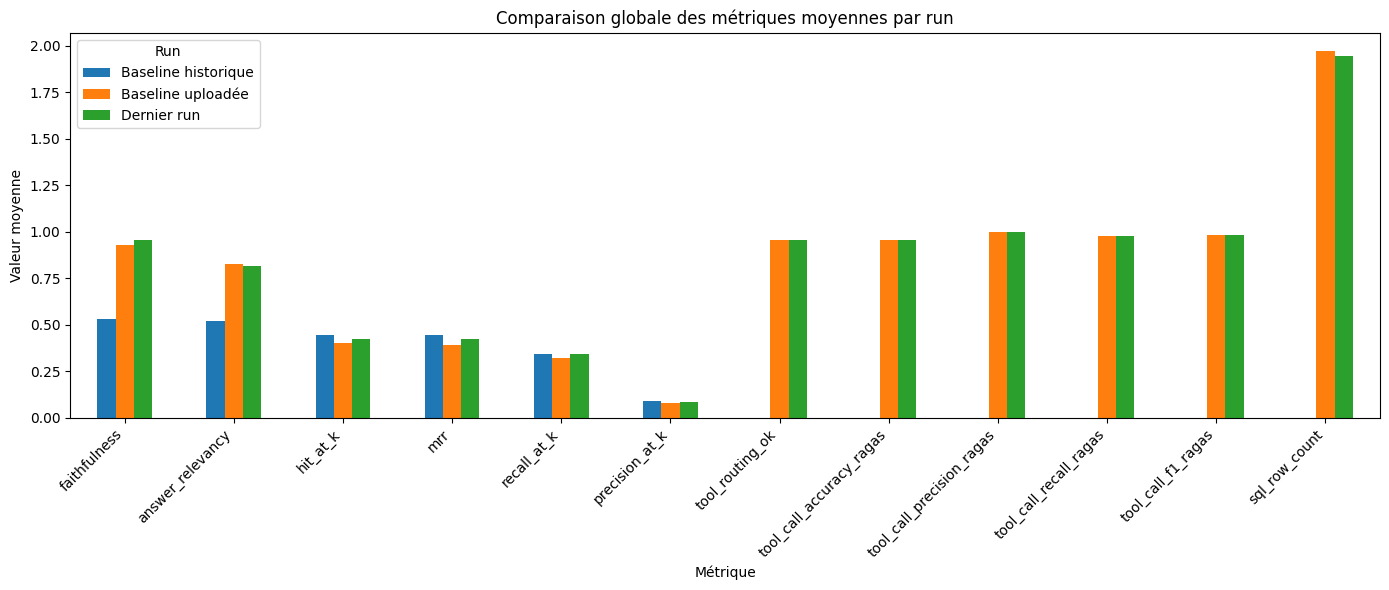

In [21]:
import matplotlib.pyplot as plt

plot_metrics = [m for m in KEY_METRICS if m in summary_table["metric"].tolist()]

plot_df = summary_table.set_index("metric").loc[plot_metrics, [BASELINE_1_NAME, BASELINE_2_NAME, FINAL_NAME]]

ax = plot_df.plot(kind="bar", figsize=(14, 6))
ax.set_title("Comparaison globale des métriques moyennes par run")
ax.set_xlabel("Métrique")
ax.set_ylabel("Valeur moyenne")
ax.legend(title="Run")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


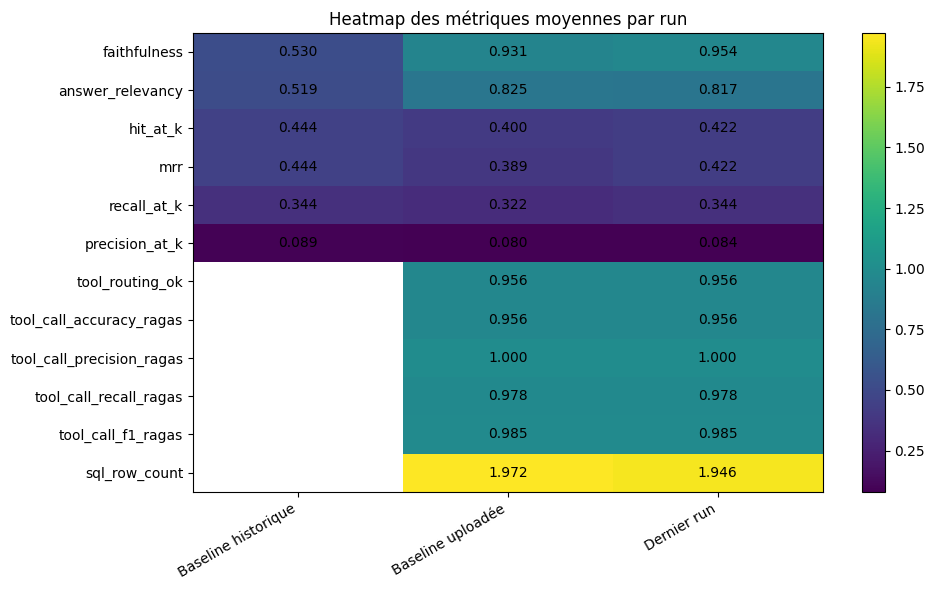

In [22]:
heatmap_df = plot_df.copy()

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(heatmap_df.values, aspect="auto")
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=30, ha="right")
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)
ax.set_title("Heatmap des métriques moyennes par run")

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[i, j]
        label = "" if pd.isna(value) else f"{value:.3f}"
        ax.text(j, i, label, ha="center", va="center")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


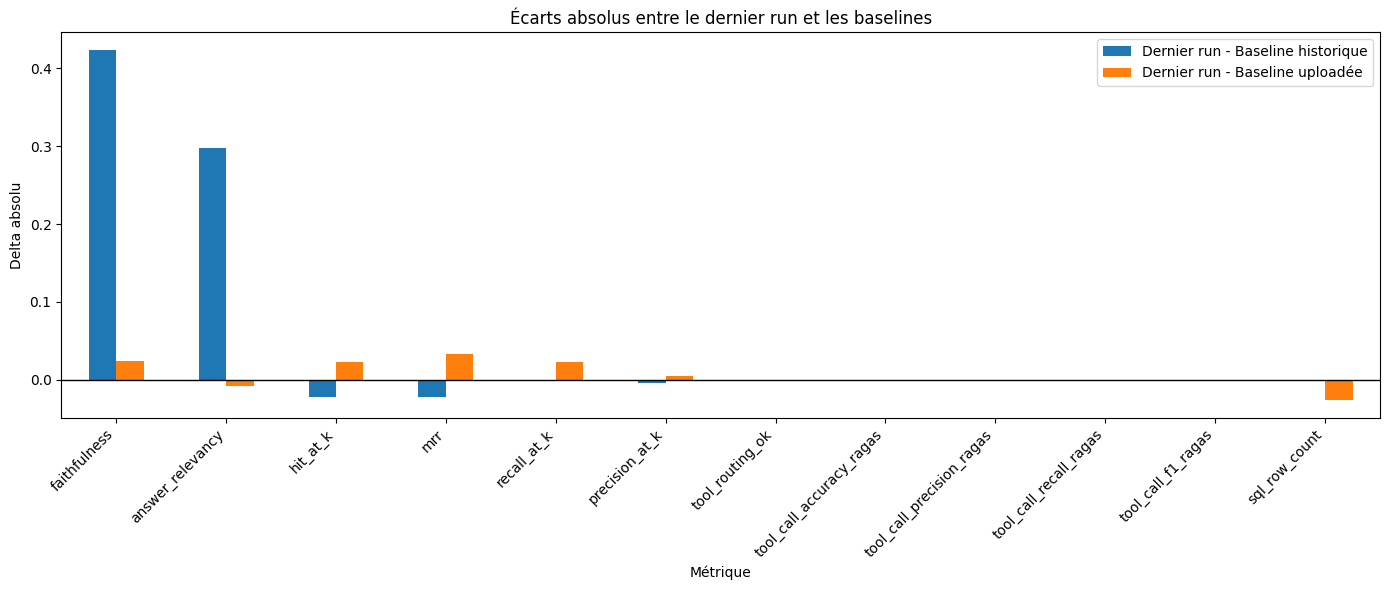

In [23]:
delta_plot_df = pd.DataFrame({
    "metric": comp_1["metric"],
    f"{FINAL_NAME} - {BASELINE_1_NAME}": comp_1["delta_absolu"],
    f"{FINAL_NAME} - {BASELINE_2_NAME}": comp_2["delta_absolu"],
}).set_index("metric")

ax = delta_plot_df.plot(kind="bar", figsize=(14, 6))
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Écarts absolus entre le dernier run et les baselines")
ax.set_xlabel("Métrique")
ax.set_ylabel("Delta absolu")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


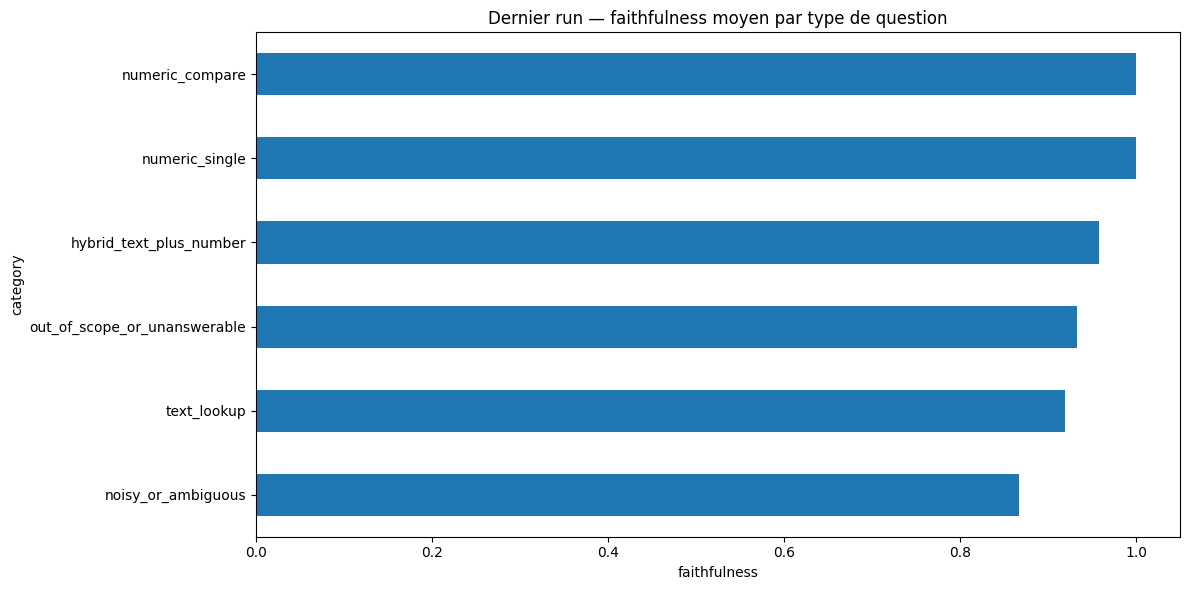

In [24]:
category_metric_to_plot = "faithfulness" if "faithfulness" in detail_metrics else detail_metrics[0]

fig, ax = plt.subplots(figsize=(12, 6))
final_category_stats[category_metric_to_plot].sort_values().plot(kind="barh", ax=ax)
ax.set_title(f"Dernier run — {category_metric_to_plot} moyen par type de question")
ax.set_xlabel(category_metric_to_plot)
ax.set_ylabel("category")
plt.tight_layout()
plt.show()


,category,Baseline historique,Baseline uploadée,Dernier run
0,hybrid_text_plus_number,0.429424,0.958333,0.958333
1,noisy_or_ambiguous,0.475425,0.933333,0.866667
2,numeric_compare,0.375594,0.900000,1.000000
3,numeric_single,0.507363,1.000000,1.000000
4,out_of_scope_or_unanswerable,0.323571,0.875000,0.933333
5,text_lookup,0.854385,0.901587,0.919577


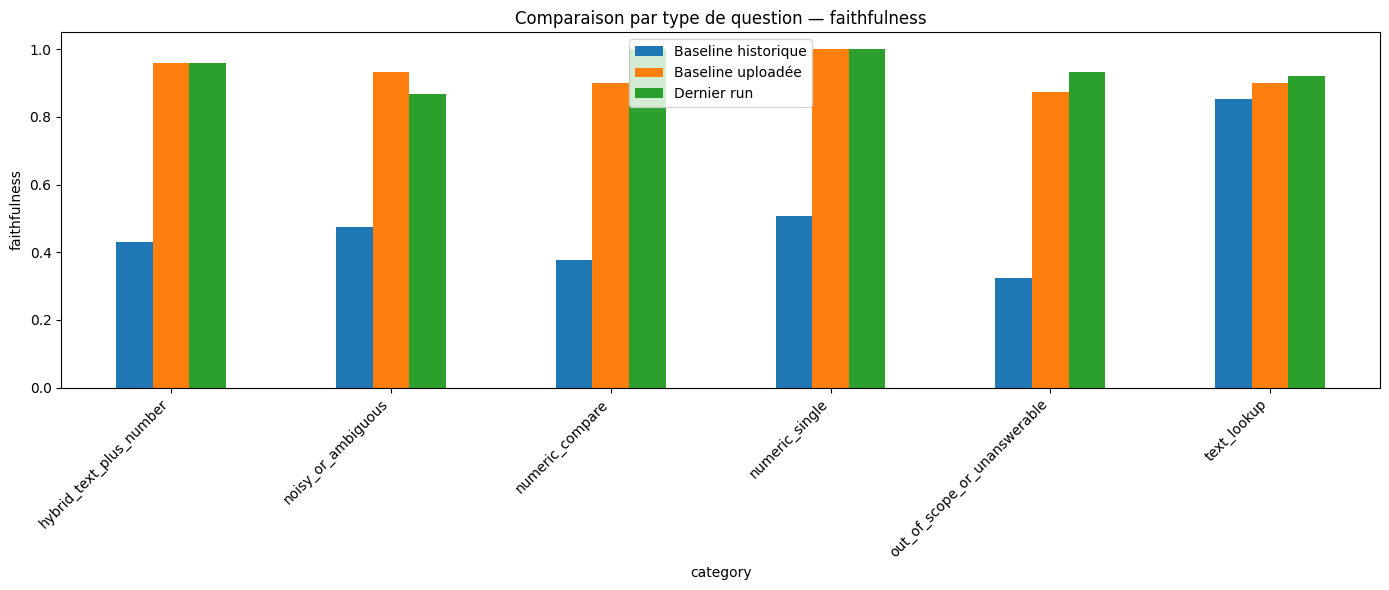

In [25]:
comparison_metric = "faithfulness" if "faithfulness" in KEY_METRICS else KEY_METRICS[0]

def build_category_run_table(df: pd.DataFrame, run_name: str, metric: str) -> pd.DataFrame:
    if "category" not in df.columns or metric not in df.columns:
        return pd.DataFrame(columns=["category", run_name])
    out = (
        df.groupby("category")[metric]
        .mean(numeric_only=True)
        .reset_index()
        .rename(columns={metric: run_name})
    )
    return out

category_compare_df = (
    build_category_run_table(baseline1_df, BASELINE_1_NAME, comparison_metric)
    .merge(
        build_category_run_table(baseline2_df, BASELINE_2_NAME, comparison_metric),
        on="category",
        how="outer",
    )
    .merge(
        build_category_run_table(final_df, FINAL_NAME, comparison_metric),
        on="category",
        how="outer",
    )
    .set_index("category")
    .sort_index()
)

display(format_table(category_compare_df.reset_index()))

ax = category_compare_df.plot(kind="bar", figsize=(14, 6))
ax.set_title(f"Comparaison par type de question — {comparison_metric}")
ax.set_xlabel("category")
ax.set_ylabel(comparison_metric)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


,category,Baseline historique,Baseline uploadée,Dernier run
0,hybrid_text_plus_number,0.443359,0.884253,0.880034
1,noisy_or_ambiguous,0.679001,0.865392,0.874879
2,numeric_compare,0.469301,0.953787,0.960240
3,numeric_single,0.275693,0.908768,0.895018
4,out_of_scope_or_unanswerable,0.188037,0.000000,0.000000
5,text_lookup,0.884568,0.934947,0.907056


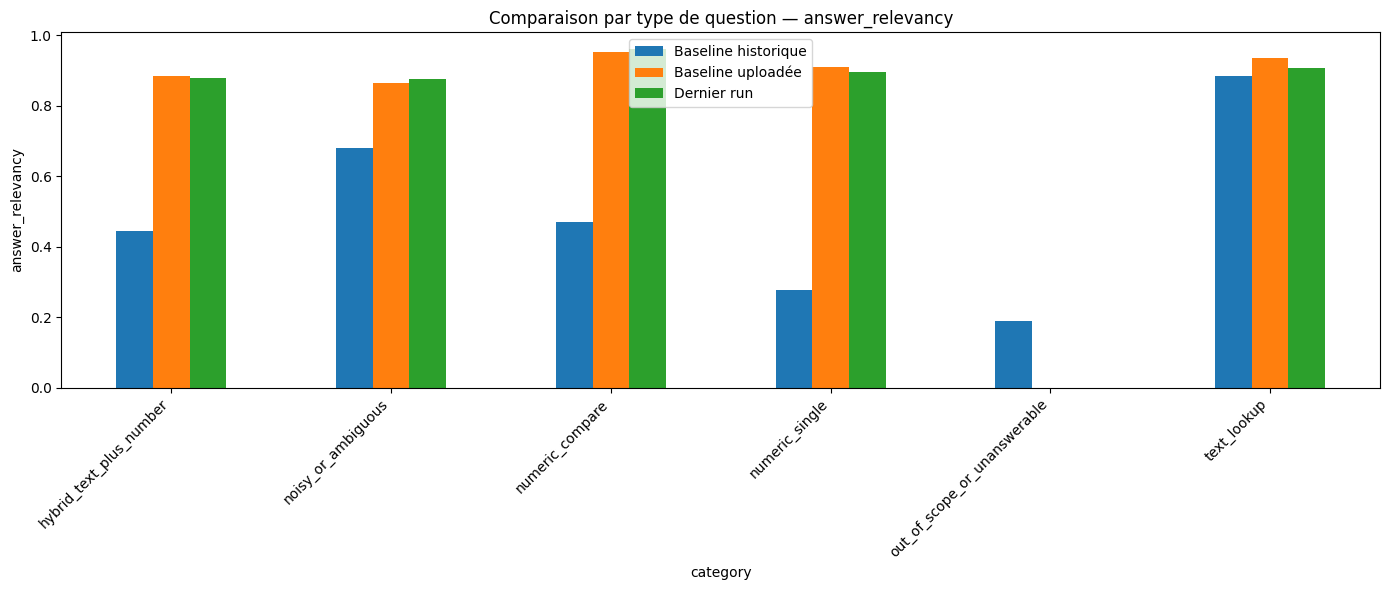

In [26]:
comparison_metric_2 = "answer_relevancy" if "answer_relevancy" in KEY_METRICS else comparison_metric

category_compare_df_2 = (
    build_category_run_table(baseline1_df, BASELINE_1_NAME, comparison_metric_2)
    .merge(
        build_category_run_table(baseline2_df, BASELINE_2_NAME, comparison_metric_2),
        on="category",
        how="outer",
    )
    .merge(
        build_category_run_table(final_df, FINAL_NAME, comparison_metric_2),
        on="category",
        how="outer",
    )
    .set_index("category")
    .sort_index()
)

display(format_table(category_compare_df_2.reset_index()))

ax = category_compare_df_2.plot(kind="bar", figsize=(14, 6))
ax.set_title(f"Comparaison par type de question — {comparison_metric_2}")
ax.set_xlabel("category")
ax.set_ylabel(comparison_metric_2)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [27]:
# Export optionnel des tableaux
EXPORT_DIR = Path("comparison_exports")
EXPORT_DIR.mkdir(exist_ok=True)

format_table(summary_table).to_csv(EXPORT_DIR / "all_runs_summary.csv", index=False)
format_table(comp_1).to_csv(EXPORT_DIR / "baseline1_vs_final.csv", index=False)
format_table(comp_2).to_csv(EXPORT_DIR / "baseline2_vs_final.csv", index=False)

print("Exports créés dans :", EXPORT_DIR.resolve())

Exports créés dans : C:\Users\thoma\Documents\Openclassroom\Projet-10\notebooks\comparison_exports
